# Vibration Prediction System - Example Usage

This notebook demonstrates how to use the vibration prediction system for training and evaluating LSTM models on vibration data.

## 1. Setup and Imports

In [1]:
import sys
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   # see issue #152
os.environ["CUDA_VISIBLE_DEVICES"]="2"
import json
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch
import yaml
from pathlib import Path

# Add project to path
project_root = Path.cwd()
sys.path.append(str(project_root))

# Import project modules
from data.dataset import VibrationDataset, create_dataloaders
from models.lstm_predictor import LSTMPredictor
from training.trainer import Trainer
from utils.visualization import VibrationVisualizer
from utils.signal_processing import compute_spectral_features, detect_bifurcation_points

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("Setup complete!")

Setup complete!


## 2. Load Configuration

In [2]:
# Load configuration files
with open('config/base_config.yaml', 'r') as f:
    base_config = yaml.safe_load(f)

with open('config/lstm_config.yaml', 'r') as f:
    lstm_config = yaml.safe_load(f)

# Merge configurations
config = base_config.copy()
for key, value in lstm_config.items():
    if key in config and isinstance(config[key], dict) and isinstance(value, dict):
        config[key].update(value)
    else:
        config[key] = value

print("Configuration loaded:")
print(f"- Window size: {config['data']['window_size']}")
print(f"- Prediction horizon: {config['data']['prediction_horizon']}")
print(f"- Model type: {config['model']['type']}")
print(f"- Hidden size: {config['model']['hidden_size']}")

Configuration loaded:
- Window size: 1000
- Prediction horizon: 200
- Model type: lstm
- Hidden size: 256


In [3]:
config

{'data': {'window_size': 1000,
  'prediction_horizon': 200,
  'stride': 100,
  'sampling_rate': 10,
  'train_split': 0.7,
  'val_split': 0.15,
  'test_split': 0.15,
  'dataset_path': 'project/create_datasets/datasets',
  'dataset_name': 'mathieu_delayed_dataset.pkl'},
 'features': {'use_features': ['basic'], 'window_sizes': [10, 50, 100]},
 'training': {'batch_size': 64,
  'learning_rate': 0.0005,
  'epochs': 100,
  'early_stopping_patience': 15,
  'gradient_clipping': 1.0,
  'optimizer': 'adam',
  'scheduler': 'reduce_lr_on_plateau',
  'weight_decay': '1e-5',
  'scheduler_patience': 10,
  'scheduler_factor': 0.5},
 'augmentation': {'noise_level': 0.01,
  'time_warping': True,
  'parameter_interpolation': True,
  'enabled': False},
 'model': {'hidden_size': 256,
  'num_layers': 2,
  'dropout': 0.3,
  'recurrent_dropout': 0.3,
  'type': 'lstm',
  'bidirectional': False,
  'input_normalization': 'z_score',
  'output_layers': [128, 64],
  'output_activation': 'tanh'},
 'loss': {'weights':

## 3. Load and Explore Dataset

In [8]:
# Create dataset
dataset_config = {
    'data_path': 'create_datasets/datasets/mathieu_delayed_dataset_shrink.pkl',
    # 'window_size': config['data']['window_size'],
    # 'prediction_horizon': config['data']['prediction_horizon'],
    'window_size': 1500,
    'prediction_horizon': 500,
    'stride': config['data']['stride'],
    'train_split': config['data']['train_split'],
    'val_split': config['data']['val_split'],
    'test_split': config['data']['test_split'],
    'sampling_rate': config['data']['sampling_rate'],
    'features': config['features']['use_features'],
    'random_seed': config['random_seed']
}

dataset_config["sampling_rate"] = 4
# dataset_config["stride"] = dataset_config["window_size"]
dataset_config["stride"] = 500
dataset_config["normalization"] = "min_max"

print(json.dumps(dataset_config, indent=2))
# Create train dataset to explore
train_dataset = VibrationDataset(split='train', **dataset_config)

print(f"Dataset loaded:")
print(f"- Total sequences: {len(train_dataset)}")
print(f"- Feature names: {train_dataset.features}")

# Get a sample
sample = train_dataset[0]
print(f"\nSample shapes:")
print(f"- Features: {sample['features'].shape}")
# print(f"- Parameters: {sample['parameters'].shape}")
print(f"- Targets: {sample['targets'].shape}")
# print(f"- Max amplitude: {sample['max_amplitude'].item():.4f}")

{
  "data_path": "create_datasets/datasets/mathieu_delayed_dataset_shrink.pkl",
  "window_size": 1500,
  "prediction_horizon": 500,
  "stride": 500,
  "train_split": 0.7,
  "val_split": 0.15,
  "test_split": 0.15,
  "sampling_rate": 4,
  "features": [
    "basic"
  ],
  "random_seed": 42,
  "normalization": "min_max"
}
Dataset loaded:
- Total sequences: 50364
- Feature names: ['basic']

Sample shapes:
- Features: torch.Size([1500, 2])
- Targets: torch.Size([500, 2])


In [5]:
train_dataset.scalers

{'x': MinMaxScaler(feature_range=(-1, 1)),
 'x_dot': MinMaxScaler(feature_range=(-1, 1)),
 'params': MinMaxScaler(feature_range=(-1, 1))}

In [117]:
diffs = []
for data in tqdm(train_dataset):
    # print(data)
    max_f = data["features"][:, 0].max()
    max_t = data["targets"][:, 0].max()
    diffs.append(max_t - max_f)

100%|██████████| 47566/47566 [00:35<00:00, 1342.78it/s]


In [118]:
len(diffs), np.argmax(diffs)

(47566, np.int64(30211))

In [122]:
diffs[30211]

tensor(0.3418)

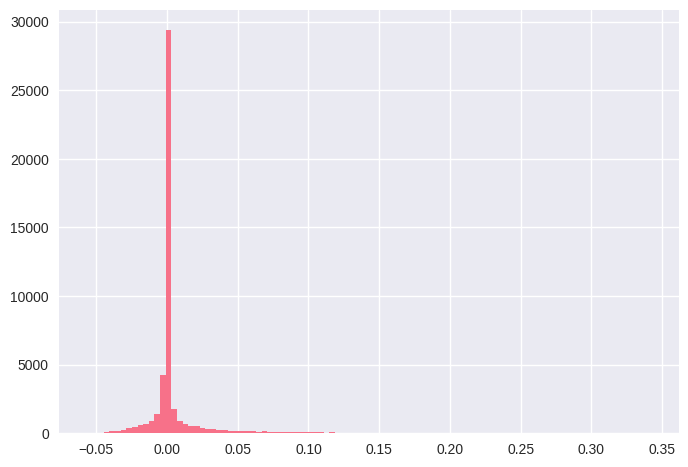

In [120]:
plt.hist(diffs,bins=100);

## 4. Visualize Sample Data

-0.04408116


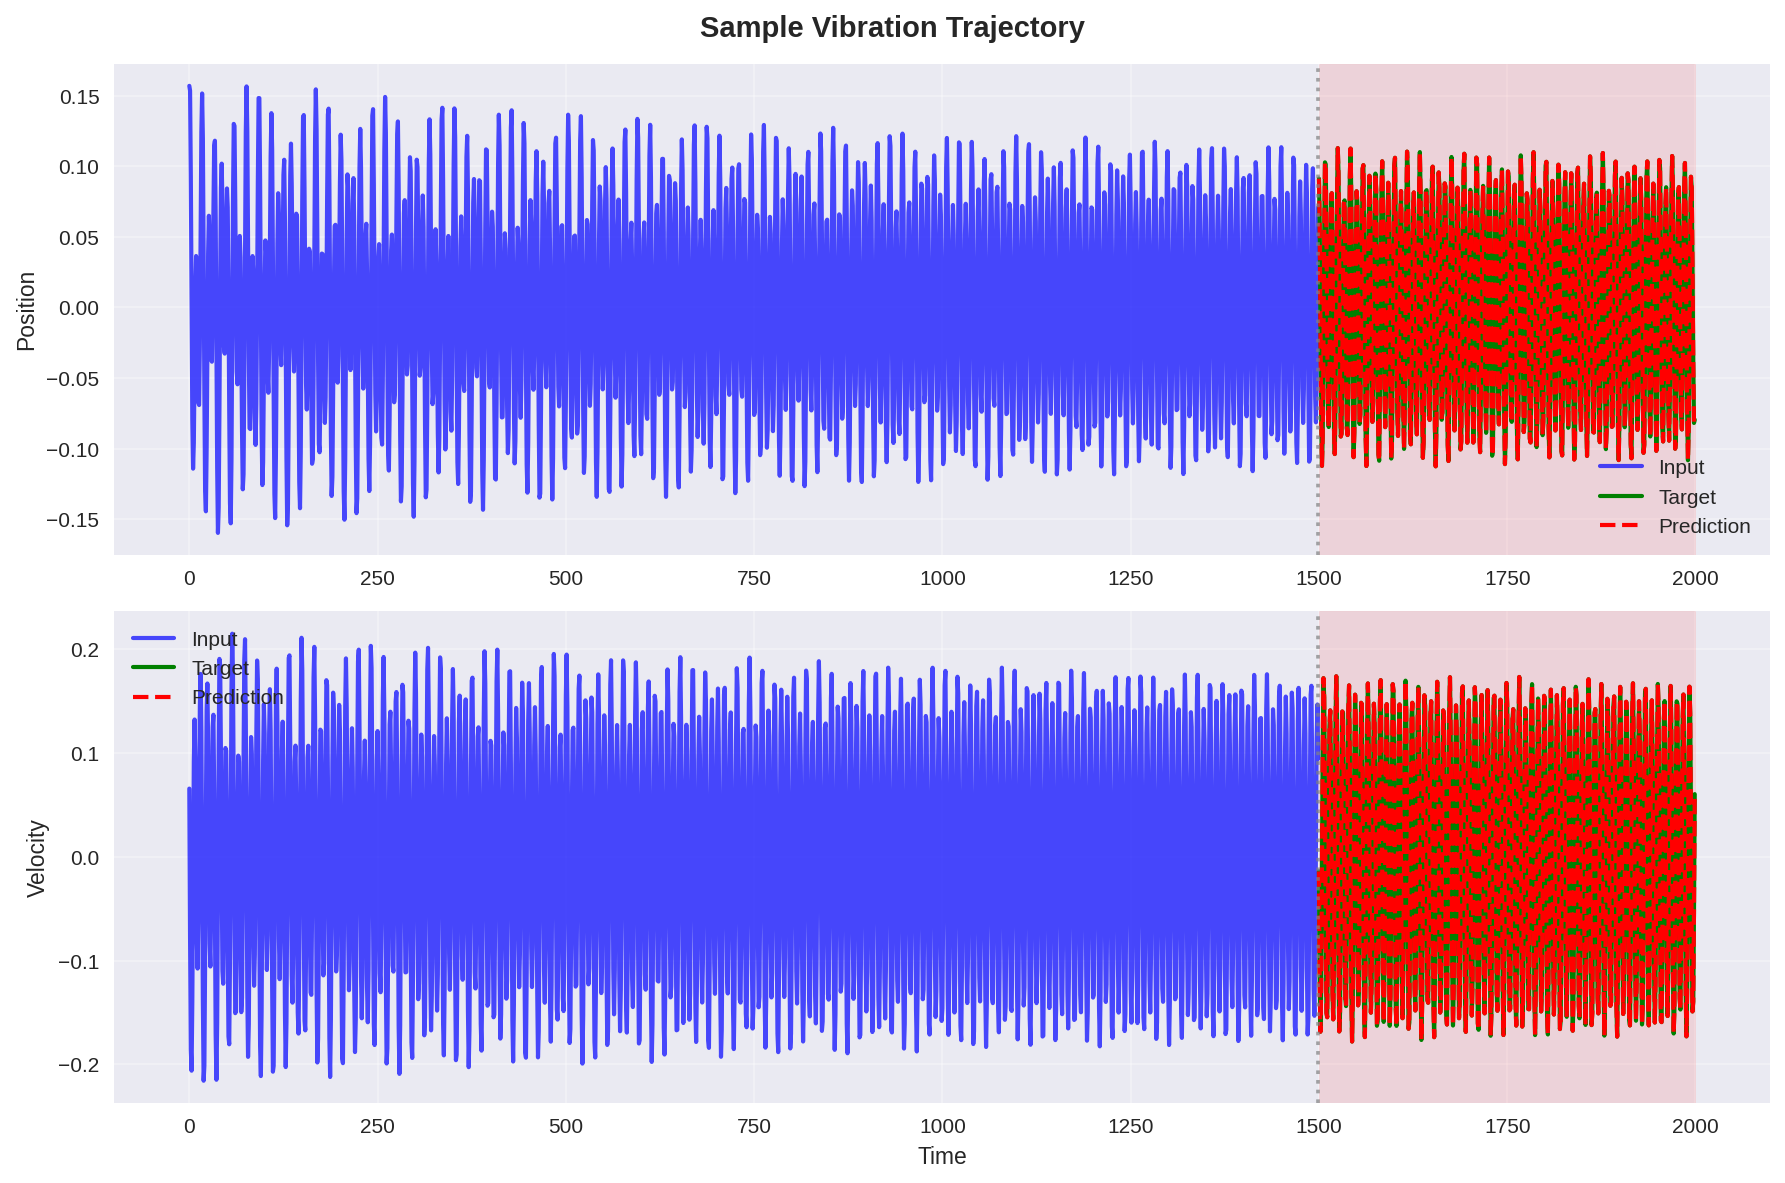

In [9]:
# Create visualizer
visualizer = VibrationVisualizer()

# Get sample data
sample = train_dataset[1]
features = sample['features'].numpy()
targets = sample['targets'].numpy()

max_f = features[:, 0].max()
max_t = targets[:, 0].max()
print(max_t - max_f)

# Plot trajectory comparison (using features as input, targets as ground truth)
fig = visualizer.plot_trajectory_comparison(
    input_data=features,
    target_data=targets,
    predicted_data=targets,  # Using targets as "prediction" for visualization
    feature_names=['Position', 'Velocity'],
    title='Sample Vibration Trajectory'
)
plt.show()

# Plot phase space
# fig = visualizer.plot_phase_space(
#     trajectories=[features, targets],
#     labels=['Input', 'Target'],
#     title='Phase Space Plot'
# )
plt.show()

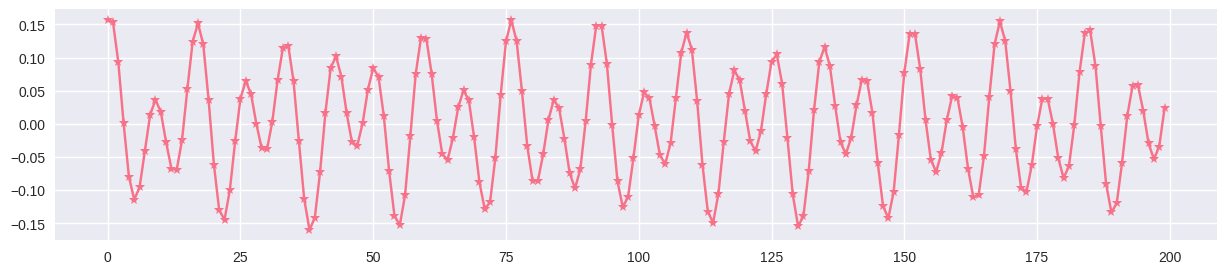

In [10]:
plt.figure(figsize=(15, 3))
plt.plot(np.arange(len(features[:200, 0])), features[:200, 0], "-*")

## 5. Analyze Signal Properties

Spectral Features:
- Dominant frequency: 1.21 Hz
- Spectral centroid: 1.12 Hz
- Spectral spread: 0.19 Hz
- Total power: 0.1418

Bifurcation Analysis:
- Number of bifurcation points: 0


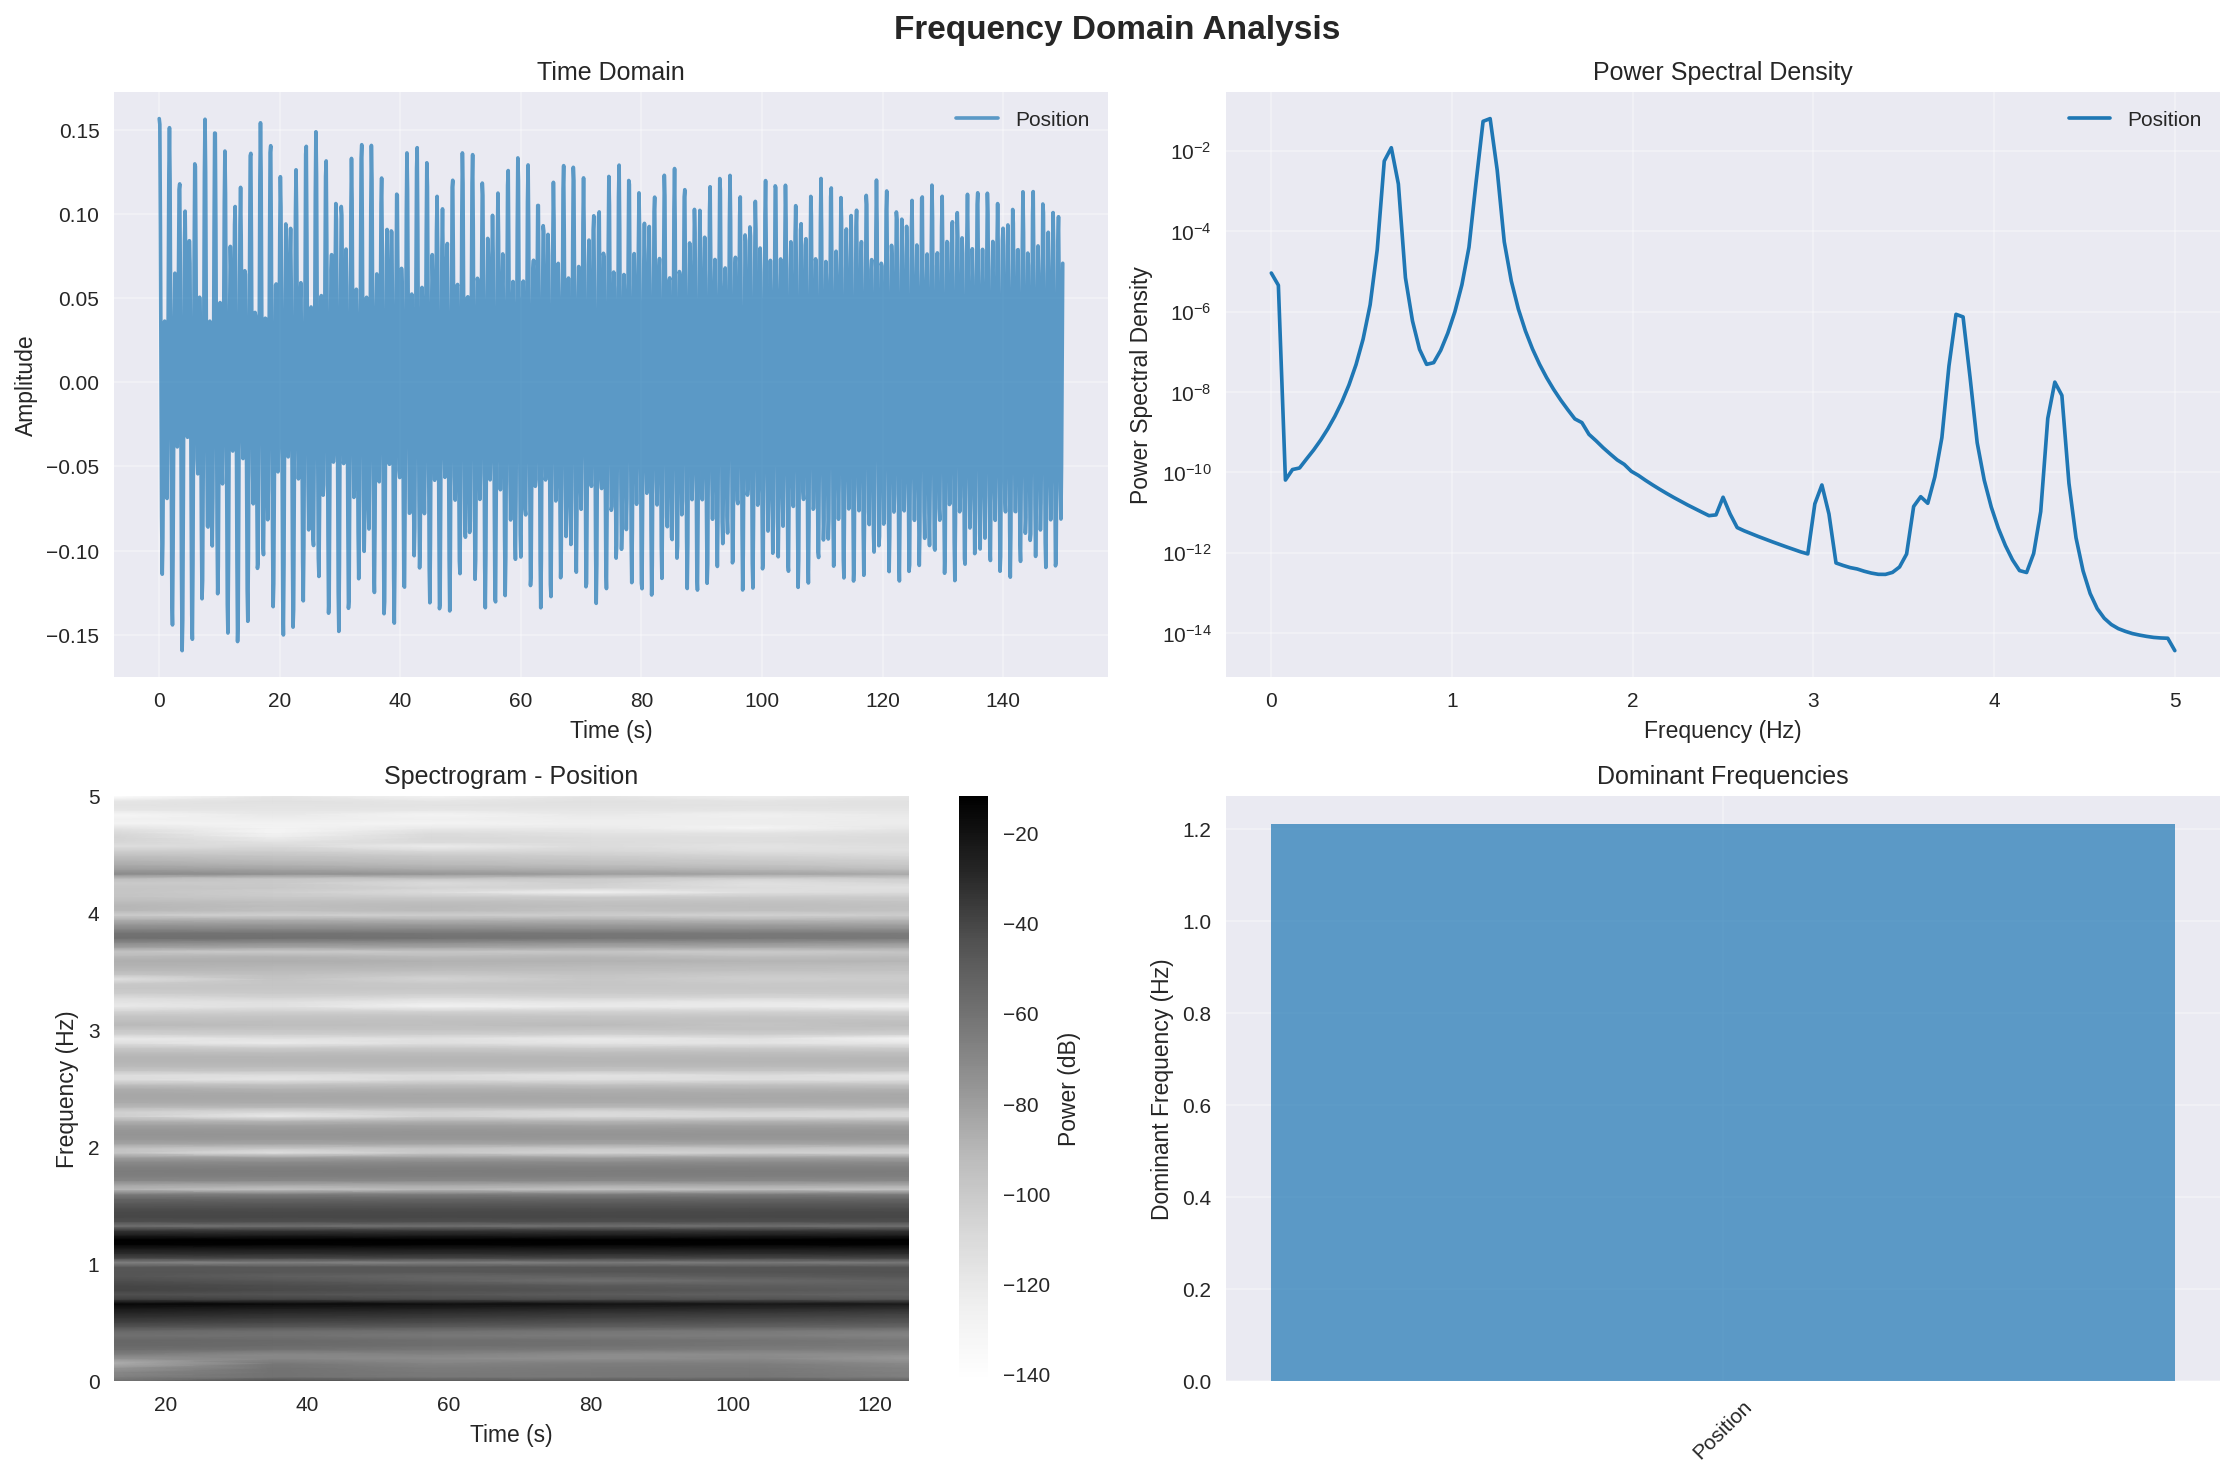

In [11]:
# Analyze spectral properties
position_signal = features[:, 0]
spectral_features = compute_spectral_features(position_signal, fs=config['data']['sampling_rate'])

print("Spectral Features:")
print(f"- Dominant frequency: {spectral_features['dominant_frequency']:.2f} Hz")
print(f"- Spectral centroid: {spectral_features['spectral_centroid']:.2f} Hz")
print(f"- Spectral spread: {spectral_features['spectral_spread']:.2f} Hz")
print(f"- Total power: {spectral_features['total_power']:.4f}")

# Detect bifurcation points
bifurcation_points, bifurcation_amplitudes = detect_bifurcation_points(position_signal)
print(f"\nBifurcation Analysis:")
print(f"- Number of bifurcation points: {len(bifurcation_points)}")
if len(bifurcation_points) > 0:
    print(f"- Max bifurcation amplitude: {np.max(bifurcation_amplitudes):.4f}")

# Plot frequency analysis
fig = visualizer.plot_frequency_analysis(
    signals=[position_signal],
    labels=['Position'],
    sampling_rate=config['data']['sampling_rate'],
    title='Frequency Domain Analysis'
)
plt.show()

## 6. Create Data Loaders

In [12]:
# Create data loaders
train_loader, val_loader, test_loader = create_dataloaders(
    dataset_config,
    batch_size=config['training']['batch_size'],
    num_workers=2  # Reduce for notebook
)

print(f"Data loaders created:")
print(f"- Train batches: {len(train_loader)}")
print(f"- Validation batches: {len(val_loader)}")
print(f"- Test batches: {len(test_loader)}")

# Check a batch
batch = next(iter(train_loader))
print(f"\nBatch shapes:")
for key, value in batch.items():
    if isinstance(value, torch.Tensor):
        print(f"- {key}: {value.shape}")
    else:
        print(f"- {key}: {type(value)}")

Data loaders created:
- Train batches: 787
- Validation batches: 169
- Test batches: 170

Batch shapes:
- features: torch.Size([64, 1500, 2])
- targets: torch.Size([64, 500, 2])


## 7. Create and Initialize Model

In [37]:
# Setup model configuration
model_config = config['model'].copy()
model_config['input_size'] = 2  # x, x_dot
model_config['output_size'] = 2  # x
# model_config['n_params'] = 15  # Number of system parameters

# Create model
model = LSTMPredictor(model_config)

# Print model info
model_info = model.get_model_info()
print(f"Model Information:")
print(f"- Type: {model_info['model_type']}")
print(f"- Total parameters: {model_info['total_parameters']:,}")
print(f"- Trainable parameters: {model_info['trainable_parameters']:,}")

# Test forward pass
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

# Move batch to device
batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}

# Forward pass
with torch.no_grad():
    outputs = model(batch)

print(f"\nModel outputs:")
for key, value in outputs.items():
    if isinstance(value, torch.Tensor):
        print(f"- {key}: {value.shape}")

print(f"\nUsing device: {device}")

Model Information:
- Type: lstm
- Total parameters: 1,177,925
- Trainable parameters: 1,177,925

Model outputs:
- trajectory: torch.Size([64, 2000, 2])
- hidden_state: torch.Size([2, 64, 256])
- cell_state: torch.Size([2, 64, 256])
- lstm_output: torch.Size([64, 2000, 256])

Using device: cuda


In [38]:
model_config

{'hidden_size': 256,
 'num_layers': 2,
 'dropout': 0.3,
 'recurrent_dropout': 0.3,
 'type': 'lstm',
 'bidirectional': False,
 'input_normalization': 'z_score',
 'output_layers': [128, 64],
 'output_activation': 'tanh',
 'input_size': 2,
 'output_size': 2}

In [39]:
batch['features'].shape

torch.Size([64, 1500, 2])

In [40]:
batch['targets'].shape

torch.Size([64, 500, 2])

In [41]:
outputs["trajectory"].shape

torch.Size([64, 2000, 2])

## 8. Train Model (Short Demo)

In [42]:
config

{'data': {'window_size': 1000,
  'prediction_horizon': 200,
  'stride': 100,
  'sampling_rate': 10,
  'train_split': 0.7,
  'val_split': 0.15,
  'test_split': 0.15,
  'dataset_path': 'project/create_datasets/datasets',
  'dataset_name': 'mathieu_delayed_dataset.pkl'},
 'features': {'use_features': ['basic'], 'window_sizes': [10, 50, 100]},
 'training': {'batch_size': 64,
  'learning_rate': 0.0005,
  'epochs': 100,
  'early_stopping_patience': 15,
  'gradient_clipping': 1.0,
  'optimizer': 'adam',
  'scheduler': 'reduce_lr_on_plateau',
  'weight_decay': '1e-5',
  'scheduler_patience': 10,
  'scheduler_factor': 0.5},
 'augmentation': {'noise_level': 0.01,
  'time_warping': True,
  'parameter_interpolation': True,
  'enabled': False},
 'model': {'hidden_size': 256,
  'num_layers': 2,
  'dropout': 0.3,
  'recurrent_dropout': 0.3,
  'type': 'lstm',
  'bidirectional': False,
  'input_normalization': 'z_score',
  'output_layers': [128, 64],
  'output_activation': 'tanh'},
 'loss': {'weights':

In [43]:
config['training']

{'batch_size': 64,
 'learning_rate': 0.0005,
 'epochs': 100,
 'early_stopping_patience': 15,
 'gradient_clipping': 1.0,
 'optimizer': 'adam',
 'scheduler': 'reduce_lr_on_plateau',
 'weight_decay': '1e-5',
 'scheduler_patience': 10,
 'scheduler_factor': 0.5}

In [44]:
# Create a short training configuration for demo
demo_config = config['training'].copy()
demo_config['epochs'] = 10  # Short demo
# demo_config['log_interval'] = 10
demo_config['early_stopping_patience'] = 2
demo_config['output_dir'] = 'demo_outputs'
demo_config['augmentation'] = {'enabled': False}

# Create trainer
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    config=demo_config,
    device=device
)

print("Starting demo training (5 epochs)...")

# Train for a few epochs
results = trainer.train()

print(f"\nDemo training completed!")
print(f"- Best validation loss: {results['best_val_loss']:.6f}")
print(f"- Training time: {results['training_time']:.2f} seconds")
print(f"- Total epochs: {results['total_epochs']}")

adam
Starting demo training (5 epochs)...


Validation: 100%|██████████| 169/169 [00:08<00:00, 18.80it/s]



Epoch 0 Detailed Metrics:
----------------------------------------
rmse_overall        : 0.010321


Validation: 100%|██████████| 169/169 [00:09<00:00, 18.78it/s]



TRAINING COMPLETED
Best Validation Loss: 0.000079
Total Epochs: 6

VIBRATION PREDICTION METRICS SUMMARY
RMSE                : 0.009039
MAE                 : 0.005857
R²                  : 0.998325
Smoothness          : 0.006693

Demo training completed!
- Best validation loss: 0.000079
- Training time: 685.57 seconds
- Total epochs: 6


In [45]:
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# all_predictions = np.concatenate(trainer.train_metrics.predictions, axis=0)
# all_targets = np.concatenate(trainer.train_metrics.targets, axis=0)

# metrics = {}

# # Overall metrics
# metrics['rmse_overall'] = np.sqrt(mean_squared_error(
#     all_targets.reshape(-1),
#     all_predictions.reshape(-1)
# ))

## 9. Evaluate Model Performance

In [47]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
from typing import Tuple, Optional, List

class VibrationVisualizer2:
    """
    Comprehensive visualization tools for vibration data and predictions.
    """

    def __init__(self, figsize: Tuple[int, int] = (1200, 800), dpi: int = 150):
        """
        Initialize visualizer.

        Args:
            figsize: Default figure size (width, height in pixels for plotly)
            dpi: Figure DPI (kept for compatibility, not used in plotly)
        """
        self.figsize = figsize
        self.dpi = dpi

    def plot_trajectory_comparison(
        self,
        input_data: np.ndarray,
        target_data: np.ndarray,
        predicted_data: np.ndarray,
        time_input: Optional[np.ndarray] = None,
        time_target: Optional[np.ndarray] = None,
        feature_names: List[str] = ['Position', 'Velocity'],
        title: str = "Trajectory Comparison",
        save_path: Optional[str] = None,
        show_plot: bool = True
    ):
        """
        Plot comparison between input, target, and predicted trajectories.

        Args:
            input_data: Input sequence [seq_len, n_features]
            target_data: Target sequence [pred_len, n_features]
            predicted_data: Predicted sequence [pred_len, n_features]
            time_input: Time array for input
            time_target: Time array for target/prediction
            feature_names: Names of features
            title: Plot title
            save_path: Path to save figure (as HTML)
            show_plot: Whether to display the plot
        """
        n_features = input_data.shape[1]

        # Create subplots
        fig = make_subplots(
            rows=n_features,
            cols=1,
            subplot_titles=feature_names,
            vertical_spacing=0.1,
            shared_xaxes=True
        )

        # Create time arrays if not provided
        if time_input is None:
            time_input = np.arange(len(input_data))
        if time_target is None:
            time_target = np.arange(len(input_data), len(input_data) + len(target_data))

        # Colors for consistent styling
        colors = {
            'input': 'blue',
            'target': 'green',
            'prediction': 'red'
        }

        for i in range(n_features):
            row = i + 1

            # Plot input
            fig.add_trace(
                go.Scatter(
                    x=time_input,
                    y=input_data[:, i],
                    mode='lines',
                    name='Input',
                    line=dict(color=colors['input'], width=2),
                    legendgroup=f'group{i}',
                    showlegend=(i == 0),  # Show legend only for first subplot
                    hovertemplate='Time: %{x:.2f}<br>Value: %{y:.4f}<extra></extra>'
                ),
                row=row, col=1
            )

            # Plot target
            fig.add_trace(
                go.Scatter(
                    x=time_target,
                    y=target_data[:, i],
                    mode='lines',
                    name='Target',
                    line=dict(color=colors['target'], width=2),
                    legendgroup=f'group{i}',
                    showlegend=(i == 0),
                    hovertemplate='Time: %{x:.2f}<br>Value: %{y:.4f}<extra></extra>'
                ),
                row=row, col=1
            )

            # Plot prediction
            fig.add_trace(
                go.Scatter(
                    x=time_target,
                    y=predicted_data[:, i],
                    mode='lines',
                    name='Prediction',
                    line=dict(color=colors['prediction'], width=2, dash='dash'),
                    legendgroup=f'group{i}',
                    showlegend=(i == 0),
                    hovertemplate='Time: %{x:.2f}<br>Value: %{y:.4f}<extra></extra>'
                ),
                row=row, col=1
            )

            # Add vertical line at prediction start
            fig.add_vline(
                x=time_input[-1],
                line_width=1,
                line_dash="dot",
                line_color="gray",
                opacity=0.7,
                row=row, col=1
            )

            # Add shaded region for prediction area
            fig.add_vrect(
                x0=time_target[0],
                x1=time_target[-1],
                fillcolor="red",
                opacity=0.05,
                layer="below",
                line_width=0,
                row=row, col=1
            )

            # Calculate and display error metrics
            mse = np.mean((predicted_data[:, i] - target_data[:, i])**2)
            mae = np.mean(np.abs(predicted_data[:, i] - target_data[:, i]))

            # Add error annotation
            fig.add_annotation(
                text=f"MSE: {mse:.4e}<br>MAE: {mae:.4e}",
                xref=f"x{row if row > 1 else ''}",
                yref=f"y{row if row > 1 else ''}",
                x=time_target[-1],
                y=max(np.max(target_data[:, i]), np.max(predicted_data[:, i])),
                showarrow=False,
                bgcolor="rgba(255, 255, 255, 0.8)",
                bordercolor="gray",
                borderwidth=1,
                font=dict(size=10)
            )

            # Update y-axis label
            fig.update_yaxes(title_text=feature_names[i], row=row, col=1)

        # Update x-axis label (only for bottom subplot)
        fig.update_xaxes(title_text="Time", row=n_features, col=1)

        # Update layout
        fig.update_layout(
            title={
                'text': title,
                'x': 0.5,
                'xanchor': 'center',
                'font': {'size': 16, 'color': 'black'}
            },
            height=self.figsize[1],
            width=self.figsize[0],
            hovermode='x unified',
            showlegend=True,
            legend=dict(
                orientation="h",
                yanchor="bottom",
                y=1.02,
                xanchor="right",
                x=1
            ),
            template='plotly_white'
        )

        # Add range slider for better navigation
        fig.update_xaxes(
            rangeslider=dict(visible=True, thickness=0.05),
            row=n_features, col=1
        )

        # Save if path provided
        if save_path:
            # Save as HTML for full interactivity
            fig.write_html(save_path)
            # Optionally also save as static image (requires kaleido)
            try:
                import kaleido
                static_path = save_path.replace('.html', '.png')
                fig.write_image(static_path, width=self.figsize[0], height=self.figsize[1])
            except ImportError:
                pass

        # Show plot
        if show_plot:
            fig.show()

        return fig


In [48]:
# Evaluate on test set
from training.metrics import VibrationMetrics

model.eval()
metrics = VibrationMetrics()

all_predictions = []
all_targets = []
all_features = []
all_amplitudes_pred = []
all_amplitudes_true = []

print("Evaluating model on test set...")

with torch.no_grad():
    # for i, batch in enumerate(test_loader):
    for i, batch in enumerate(train_loader):
        if i >= 10:  # Limit for demo
            break

        # Move to device
        batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v
                for k, v in batch.items()}
        features = batch["features"]
        targets = batch["targets"]
        batch_size, seq_len, _ = features.shape
        batch_size, horizon_len, _ = targets.shape

        # Forward pass
        outputs = model(batch)

        predictions = outputs["trajectory"][:, seq_len - 1:-1, :]
        targets = batch["targets"][:,:,:]

        # Collect results
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())
        all_features.append(features.cpu().numpy())

        if 'amplitude' in outputs:
            all_amplitudes_pred.append(outputs['amplitude'].cpu().numpy())
        if 'max_amplitude' in batch:
            all_amplitudes_true.append(batch['max_amplitude'].cpu().numpy())

        # Update metrics
        metrics.update(
            predictions=predictions,
            targets=targets,
            amplitudes_pred=outputs.get('amplitude'),
            amplitudes_true=batch.get('max_amplitude')
        )

# Compute metrics
evaluation_results = metrics.compute_all_metrics()

# Print summary
print("\nEvaluation Results:")
summary = metrics.get_summary_metrics()
for metric_name, value in summary.items():
    print(f"- {metric_name}: {value:.6f}")

Evaluating model on test set...

Evaluation Results:
- RMSE: 0.009289
- MAE: 0.005951
- R²: 0.998325
- Smoothness: 0.007202


## 10. Visualize Predictions

In [49]:
# Concatenate results for visualization
visualizer = VibrationVisualizer2(figsize=(1000, 400))

predictions = np.concatenate(all_predictions, axis=0)
targets = np.concatenate(all_targets, axis=0)
features = np.concatenate(all_features, axis=0)

# Plot sample predictions
n_samples = min(10, len(predictions))
di = 60

for i in range(n_samples):
    # Create dummy input (use first part of target)
    input_data = features[i+di, :, 0:1]
    target_data = targets[i+di, :, 0:1]
    predicted_data = predictions[i+di, :, 0:1]

    fig = visualizer.plot_trajectory_comparison(
        input_data,
        target_data,
        predicted_data,
        title=f'Sample {i+1} - Prediction vs Ground Truth'
    )
    plt.show()

# fig = visualizer.plot_trajectory_comparison(
#     input_data=features,
#     target_data=targets,
#     predicted_data=targets,  # Using targets as "prediction" for visualization
#     feature_names=['Position', 'Velocity'],
#     title='Sample Vibration Trajectory'
# )

# Plot amplitude analysis if available
if all_amplitudes_pred and all_amplitudes_true:
    amplitudes_pred = np.concatenate(all_amplitudes_pred, axis=0)
    amplitudes_true = np.concatenate(all_amplitudes_true, axis=0)

    fig = visualizer.plot_amplitude_analysis(
        amplitudes_pred.flatten(),
        amplitudes_true.flatten(),
        title='Amplitude Prediction Analysis'
    )
    plt.show()

In [50]:
def predict_trajectory(
        model,
        batch,
        horizon
    ) -> torch.Tensor:
        """
        Predict future trajectory using autoregressive generation.

        Args:
            features: Input features [batch_size, seq_len, input_size]
            parameters: System parameters [batch_size, n_params]
            horizon: Prediction horizon

        Returns:
            Predicted trajectory [batch_size, horizon, output_size]
        """
        x = batch['features']
        batch_size, seq_len, _ = features.shape

        projected_input = model.input_projection(x)
        # print(projected_input.shape)
        lstm_output, (hidden, cell) = model.lstm(projected_input)
        # print(lstm_output.shape, hidden.shape, cell.shape)
        trajectory_pred = model.output_net(lstm_output)
        # print(trajectory_pred.shape)


        # Initialize prediction sequence
        predictions = [trajectory_pred[:, -1:, :]]
        current_input = trajectory_pred[:, -1:, :]


        for step in tqdm(range(horizon - 1)):
            projected_input = model.input_projection(current_input)
            lstm_output, (hidden, cell) = model.lstm(projected_input, (hidden, cell))
            current_input = model.output_net(lstm_output)
            predictions.append(current_input)


        # # Concatenate all predictions
        trajectory = torch.cat(predictions, dim=1)  # [batch_size, horizon, output_size]

        return trajectory

In [51]:
with torch.no_grad():
    batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v
                for k, v in batch.items()}
    trajectory_pred = predict_trajectory(model, batch, horizon=1000)

100%|██████████| 999/999 [00:00<00:00, 2000.12it/s]


In [53]:
# Evaluate on test set
from training.metrics import VibrationMetrics

model.eval()
metrics = VibrationMetrics()

all_predictions = []
all_targets = []
all_features = []
all_amplitudes_pred = []
all_amplitudes_true = []

print("Evaluating model on test set...")

with torch.no_grad():
    # for i, batch in enumerate(test_loader):
    for i, batch in enumerate(train_loader):
        if i >= 10:  # Limit for demo
            break

        # Move to device
        batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v
                for k, v in batch.items()}
        features = batch["features"]
        targets = batch["targets"]
        batch_size, seq_len, _ = features.shape
        batch_size, horizon_len, _ = targets.shape

        # Forward pass
        # outputs = model(batch)
        trajectory_pred = predict_trajectory(model, batch, horizon=horizon_len)

        # predictions = outputs["trajectory"][:, seq_len - 1:-1, :]
        predictions = trajectory_pred
        targets = batch["targets"][:,:,:]

        # Collect results
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())
        all_features.append(features.cpu().numpy())

        if 'amplitude' in outputs:
            all_amplitudes_pred.append(outputs['amplitude'].cpu().numpy())
        if 'max_amplitude' in batch:
            all_amplitudes_true.append(batch['max_amplitude'].cpu().numpy())

        # Update metrics
        metrics.update(
            predictions=predictions,
            targets=targets,
            amplitudes_pred=outputs.get('amplitude'),
            amplitudes_true=batch.get('max_amplitude')
        )

# Compute metrics
evaluation_results = metrics.compute_all_metrics()

# Print summary
print("\nEvaluation Results:")
summary = metrics.get_summary_metrics()
for metric_name, value in summary.items():
    print(f"- {metric_name}: {value:.6f}")

Evaluating model on test set...


100%|██████████| 499/499 [00:00<00:00, 1989.67it/s]



Evaluation Results:
- RMSE: 0.224331
- MAE: 0.123892
- R²: 0.056418
- Smoothness: 0.102673


In [54]:
# Concatenate results for visualization
visualizer = VibrationVisualizer2(figsize=(1000, 400))

predictions = np.concatenate(all_predictions, axis=0)
targets = np.concatenate(all_targets, axis=0)
features = np.concatenate(all_features, axis=0)

# Plot sample predictions
n_samples = min(10, len(predictions))
di = 0

for i in range(n_samples):
    # Create dummy input (use first part of target)
    input_data = features[i+di, :, 0:1]
    target_data = targets[i+di, :, 0:1]
    predicted_data = predictions[i+di, :, 0:1]

    fig = visualizer.plot_trajectory_comparison(
        input_data,
        target_data,
        predicted_data,
        title=f'Sample {i+1} - Prediction vs Ground Truth'
    )
    plt.show()

# fig = visualizer.plot_trajectory_comparison(
#     input_data=features,
#     target_data=targets,
#     predicted_data=targets,  # Using targets as "prediction" for visualization
#     feature_names=['Position', 'Velocity'],
#     title='Sample Vibration Trajectory'
# )

# Plot amplitude analysis if available
if all_amplitudes_pred and all_amplitudes_true:
    amplitudes_pred = np.concatenate(all_amplitudes_pred, axis=0)
    amplitudes_true = np.concatenate(all_amplitudes_true, axis=0)

    fig = visualizer.plot_amplitude_analysis(
        amplitudes_pred.flatten(),
        amplitudes_true.flatten(),
        title='Amplitude Prediction Analysis'
    )
    plt.show()

## 11. Attention Analysis (if available)

In [ ]:
# Get attention weights for a sample
sample_batch = next(iter(test_loader))
sample_batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v
               for k, v in sample_batch.items()}

with torch.no_grad():
    # Get attention weights
    attention_weights = model.get_attention_weights(
        sample_batch['features'][:1],  # First sample only
        sample_batch['parameters'][:1]
    )

if attention_weights.numel() > 0:
    # Plot attention weights
    fig = visualizer.plot_attention_weights(
        attention_weights.cpu().numpy(),
        sample_batch['features'][0].cpu().numpy(),
        title='Attention Weights Visualization'
    )
    plt.show()
else:
    print("No attention weights available for this model.")

## 12. Model Performance Summary

In [ ]:
# Create performance summary visualization
fig = visualizer.plot_model_performance_summary(
    evaluation_results,
    title='Model Performance Summary'
)
plt.show()

# Print detailed results
print("\nDetailed Evaluation Results:")
print("=" * 50)

# Group metrics by category
trajectory_metrics = {k: v for k, v in evaluation_results.items()
                     if any(x in k.lower() for x in ['rmse', 'mae', 'r2'])}
amplitude_metrics = {k: v for k, v in evaluation_results.items()
                    if 'amplitude' in k.lower()}
bifurcation_metrics = {k: v for k, v in evaluation_results.items()
                      if 'bifurcation' in k.lower()}

if trajectory_metrics:
    print("\nTrajectory Metrics:")
    for key, value in trajectory_metrics.items():
        print(f"  {key}: {value:.6f}")

if amplitude_metrics:
    print("\nAmplitude Metrics:")
    for key, value in amplitude_metrics.items():
        print(f"  {key}: {value:.6f}")

if bifurcation_metrics:
    print("\nBifurcation Detection Metrics:")
    for key, value in bifurcation_metrics.items():
        print(f"  {key}: {value:.6f}")

print("\n" + "=" * 50)
print("Demo completed successfully!")
print("\nFor full training, use the command line interface:")
print("python main.py --mode train --config config/base_config.yaml --model-config config/lstm_config.yaml")